# Combined mmFall + TI IWR6843 — 2D Spatial-Temporal CNN Training

This notebook trains a PyTorch **2D Spatial-Temporal Convolutional Neural Network (`Radar4DCNN`)** on the preprocessed **Combined Multi-Sensor** feature tensors.

### Model Architecture (`Radar4DCNN`)
```
Input Feature Tensor: (Batch Size, 4 Channels, 10 Frames, 64 Points)
  ├── Conv Block 1: Conv2D(4 -> 32, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(1,2)
  ├── Conv Block 2: Conv2D(32 -> 64, kernel=(3,5)) + BatchNorm + ReLU + MaxPool2d(2,2)
  ├── Conv Block 3: Conv2D(64 -> 128, kernel=(3,3)) + BatchNorm + ReLU + AdaptiveAvgPool2d(1,1)
  ├── Flatten (128 Features) + Dropout (p=0.4)
  ├── Linear (128 -> 64) + ReLU
  └── Output Linear (64 -> 2 Classes): [0 = Non-Fall ADL, 1 = Fall]
```

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")
torch.manual_seed(42)
np.random.seed(42)

# Dynamic path resolution
preproc_dir = Path("datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../datasets/preprocessed")
if not preproc_dir.exists():
    preproc_dir = Path("../../datasets/preprocessed")

X = np.load(preproc_dir / "X_combined_clean_balanced.npy")
y = np.load(preproc_dir / "y_combined_clean_balanced.npy")

print(f"Loaded Combined Multi-Sensor Feature Tensor: {X.shape}")
print(f"Target Labels: {np.bincount(y.astype(int))} (0 = ADL, 1 = Fall)")

Loaded Combined Multi-Sensor Feature Tensor: (1910, 10, 32, 4)
Target Labels: [955 955] (0 = ADL, 1 = Fall)


In [2]:
# PyTorch Train/Test Split (80% Train, 20% Test)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Reshape to (Batch, 4 Channels, 10 Frames, 64 Points)
X_tr_t = torch.tensor(X_tr, dtype=torch.float32).permute(0, 3, 1, 2)
X_te_t = torch.tensor(X_te, dtype=torch.float32).permute(0, 3, 1, 2)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
y_te_t = torch.tensor(y_te, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_te_t, y_te_t), batch_size=32, shuffle=False)
print(f"Train size: {len(X_tr_t)} | Test size: {len(X_te_t)}")

Train size: 1528 | Test size: 382


In [3]:
class Radar4DCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2):
        super(Radar4DCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((1, 2)),
            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        feat = self.features(x).view(x.size(0), -1)
        return self.classifier(feat)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Radar4DCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [4]:
# Train Model with Best Validation Checkpointing
models_dir = Path("models")
if not models_dir.exists(): models_dir = Path("../models")
if not models_dir.exists(): models_dir = Path("../../models")
models_dir.mkdir(parents=True, exist_ok=True)
best_model_path = models_dir / "cnn_combined_best.pth"

epochs = 20
losses, accs = [], []
best_val_loss = float('inf')

for ep in range(epochs):
    model.train()
    total_loss, correct = 0, 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        out = model(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * bx.size(0)
        correct += (out.argmax(1) == by).sum().item()
    train_loss = total_loss / len(X_tr_t)
    train_acc = correct / len(X_tr_t)
    losses.append(train_loss)
    accs.append(train_acc)

   # Validation step
    model.eval()
    val_loss, val_corr = 0.0, 0
    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            out = model(bx)
            loss = criterion(out, by)
            val_loss += loss.item() * bx.size(0)
            val_corr += (out.argmax(1) == by).sum().item()
    val_loss /= len(X_te_t)
    val_acc = val_corr / len(X_te_t)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        saved_flag = " [BEST SAVED]"
    else:
        saved_flag = ""

    if (ep + 1) % 5 == 0 or ep == 0 or saved_flag:
        print(f"Epoch {ep+1:02d}/{epochs} - Tr Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%{saved_flag}")

# Reload best model weights for evaluation
if best_model_path.exists():
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print(f"\nLoaded best model checkpoint from: {best_model_path} (Best Val Loss: {best_val_loss:.4f})")

Epoch 01/20 - Tr Loss: 0.6113 Acc: 65.31% | Val Loss: 0.5188 Acc: 72.77% [BEST SAVED]


Epoch 02/20 - Tr Loss: 0.4947 Acc: 75.52% | Val Loss: 0.4269 Acc: 78.27% [BEST SAVED]


Epoch 05/20 - Tr Loss: 0.3890 Acc: 82.46% | Val Loss: 0.5016 Acc: 76.70%


Epoch 06/20 - Tr Loss: 0.3646 Acc: 83.57% | Val Loss: 0.4186 Acc: 80.89% [BEST SAVED]


Epoch 08/20 - Tr Loss: 0.3215 Acc: 86.71% | Val Loss: 0.3836 Acc: 82.72% [BEST SAVED]


Epoch 09/20 - Tr Loss: 0.3175 Acc: 86.26% | Val Loss: 0.3169 Acc: 84.82% [BEST SAVED]


Epoch 10/20 - Tr Loss: 0.3064 Acc: 86.85% | Val Loss: 0.4715 Acc: 80.37%


Epoch 15/20 - Tr Loss: 0.2235 Acc: 90.64% | Val Loss: 0.7063 Acc: 75.92%


Epoch 20/20 - Tr Loss: 0.1870 Acc: 92.28% | Val Loss: 0.4855 Acc: 81.94%

Loaded best model checkpoint from: ..\models\cnn_combined_best.pth (Best Val Loss: 0.3169)


Test Accuracy: 84.82% | Test ROC-AUC: 0.9412

Classification Report:
                  precision    recall  f1-score   support

 ADL (Non-Fall)       0.82      0.89      0.85       191
           Fall       0.88      0.81      0.84       191

       accuracy                           0.85       382
      macro avg       0.85      0.85      0.85       382
   weighted avg       0.85      0.85      0.85       382



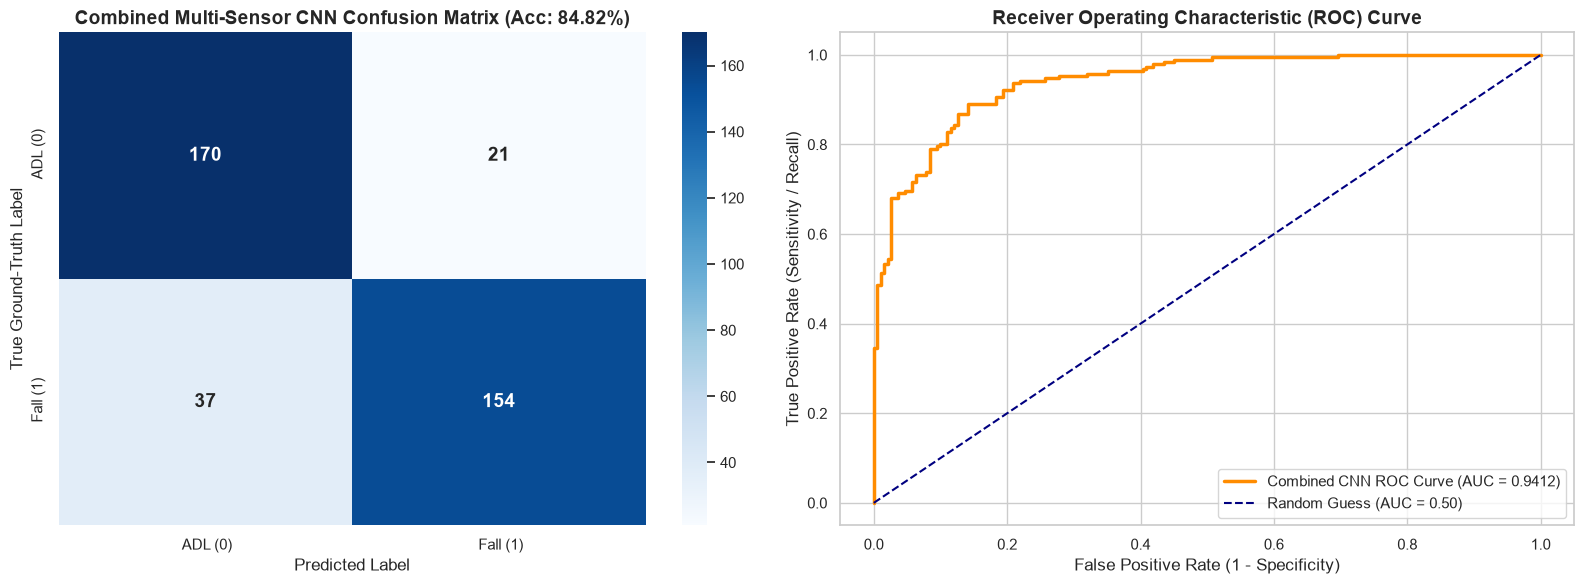

In [5]:
# Evaluate Model
model.eval()
preds, probs, targets = [], [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        out = model(bx)
        probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
        preds.extend(out.argmax(1).cpu().numpy())
        targets.extend(by.numpy())

targets = np.array(targets)
preds = np.array(preds)
probs = np.array(probs)

acc = accuracy_score(targets, preds)
auc = roc_auc_score(targets, probs)
cm = confusion_matrix(targets, preds)
fpr, tpr, _ = roc_curve(targets, probs)

print(f"Test Accuracy: {acc*100:.2f}% | Test ROC-AUC: {auc:.4f}")
print("\nClassification Report:\n", classification_report(targets, preds, target_names=[" ADL (Non-Fall)", " Fall"]))

# Visual Confusion Matrix & ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=[" ADL (0)", " Fall (1)"],
            yticklabels=[" ADL (0)", " Fall (1)"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title(f"Combined Multi-Sensor CNN Confusion Matrix (Acc: {acc*100:.2f}%)", fontweight="bold", fontsize=14)
axes[0].set_xlabel("Predicted Label", fontsize=12)
axes[0].set_ylabel("True Ground-Truth Label", fontsize=12)

# ROC Curve
axes[1].plot(fpr, tpr, color="darkorange", linewidth=2.5, label=f"Combined CNN ROC Curve (AUC = {auc:.4f})")
axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--", linewidth=1.5, label="Random Guess (AUC = 0.50)")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve", fontweight="bold", fontsize=14)
axes[1].set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
axes[1].set_ylabel("True Positive Rate (Sensitivity / Recall)", fontsize=12)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()
